<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/wrapperfeat_sel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.model_selection import cross_val_score


In [2]:
!pip install --upgrade scikit-learn mlxtend

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 84.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully unin

In [6]:
df = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

lr = LogisticRegression()

sel = EFS(lr, max_features=4, scoring='accuracy', cv=5)
model = sel.fit(df.iloc[:,:4],df['species'])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Features: 15/15

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [12]:
model.best_score_
model.best_feature_names_

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [20]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df['medv'], test_size=0.2, random_state=1)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
# baseline model
import numpy as np
from sklearn.metrics import r2_score
model = LinearRegression()


print("training",np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))
lr = LinearRegression()

exh = EFS(lr, max_features=13, scoring='r2', cv=10, print_progress=True,n_jobs=-1)

sel = exh.fit(X_train, y_train)
sel.best_score_

training 0.7025123301096212
testing 0.6514899901155402


Features: 8191/8191

np.float64(0.6827988156800064)

In [23]:
def adjust_r2(r2, num_examples, num_features):
    coef = (num_examples - 1) / (num_examples - num_features - 1)
    return 1 - (1 - r2) * coef
metric_df = pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x:len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])
model = LinearRegression()
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)
print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.7100327839218561
testing 0.7205819296124483


In [29]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df['medv'], test_size=0.2, random_state=1)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
sel = EFS(lr, max_features=13, scoring='r2', cv=10, print_progress=True,n_jobs=-1)

sel = sel.fit(X_train, y_train)
sel.best_score_
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)
X_train.columns = df.columns[:-1]
X_test.columns = df.columns[:-1]


Features: 8191/8191

np.float64(0.6827988156800064)

In [36]:
sel.best_feature_names_
X_train_new = sel.transform(X_train)
X_test_new = sel.transform(X_test)
r2_score(y_train, lr.fit(X_train_new, y_train).predict(X_train_new)), r2_score(y_test, lr.fit(X_train_new, y_train).predict(X_test_new))
sel.best_feature_names_
df.iloc[:,[0,1,4,5,7,8,9,10,11,12]].columns

Index(['crim', 'zn', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio', 'b',
       'lstat'],
      dtype='str')

In [45]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df=pd.DataFrame(sc.fit_transform(df),columns=df.columns)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df['medv'], test_size=0.2, random_state=1)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,1.487503


In [70]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs1 = SFS(lr,
           k_features=(1, 13),
           forward=False,
           floating=False,

           scoring='r2',
           cv=10)
sel=sfs1.fit(X_train, y_train)
X_train_new=sel.transform(X_train)
X_test_new=sel.transform(X_test)
r2_score(y_train, lr.fit(X_train_new, y_train).predict(X_train_new)), r2_score(y_test, lr.fit(X_train_new, y_train).predict(X_test_new))


(0.7252937481508329, 0.7551933887467761)

In [71]:
print(sel.k_feature_idx_)
print(sel.k_feature_names_)
print(sel.k_score_)
print(r2_score(y_train, lr.fit(X_train_new, y_train).predict(X_train_new)), r2_score(y_test, lr.fit(X_train_new, y_train).predict(X_test_new))
)

(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)
('crim', 'zn', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat')
0.6827988156800064
0.7252937481508329 0.7551933887467761


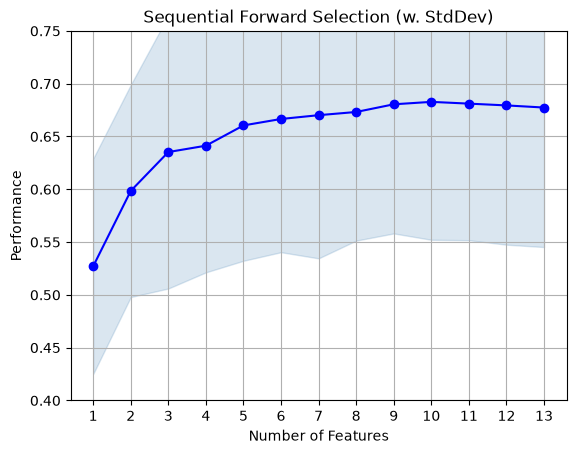

(404, 10)

In [77]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
fig1 = plot_sfs(sel.get_metric_dict(), kind='std_dev')

plt.ylim([0.4, 0.75])
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()
len(sel.get_metric_dict())
X_train_new.shape

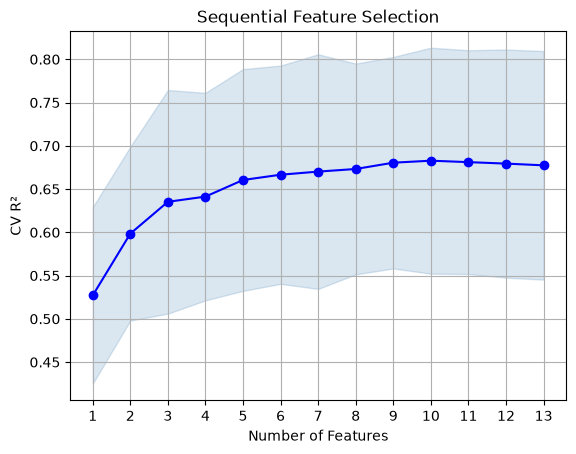

In [69]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

sfs = SFS(
    lr,
    k_features=(1,13),
    forward=True,
    floating=False,
    scoring='r2',
    cv=10
)

sel = sfs.fit(X_train, y_train)

from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

fig = plot_sfs(sel.get_metric_dict(), kind='std_dev')

plt.title("Sequential Feature Selection")
plt.xlabel("Number of Features")
plt.ylabel("CV R²")
plt.grid(True)
plt.show()

In [76]:
print(len(sel.get_metric_dict()))
print(sel.k_score_)

13
0.6827988156800064
